# Final benchmark comparison and Diebold–Mariano tests

Produces the paper-ready answer to the reviewer comment on target leakage and simple benchmarks:

1. **Comparison table**: every learned model (Hybrid TFT-MODFLOW, plus the no-MODFLOW ablation if its predictions exist) against persistence, seasonal persistence, AR(1), AR(7) and AR(p) with p chosen by BIC, scored on **exactly the same forecast days**, in original units (feet).
2. **Skill scores against persistence**. With a 1-day horizon, R² is about 0.99 for every sensible model, so skill against persistence and R² on the *daily change* are the informative metrics.
3. **Diebold–Mariano tests** (squared- and absolute-error loss) of each learned model against each benchmark, with a Newey–West (HAC) variance and the Harvey–Leybourne–Newbold small-sample correction.
4. **Robustness subset**: the same table on measured days only (excluding gap-filled USGS days).
5. **Exports**: CSV and LaTeX tables plus a cumulative-loss figure under `results/paper_tables/`.

Every benchmark uses only information available before the forecast origin: persistence `y[t-1]`, seasonal persistence `y[t-365]`, and AR models fitted on the **train split only** and applied one step ahead using observed past values.

Run with the working directory set to `code_version_2` (the folder containing `data/` and `models/`). No PyTorch is needed; the notebook only reads saved prediction CSVs.

## 1. Configuration

In [1]:
import os
import math
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)  # sklearn scaler version warning

PROCESSED_DIR = "data/processed"
OUTPUT_DIR = "results/paper_tables"
DATE_COL = "date"
TARGET_COL = "water_level"

# Learned models to evaluate: display name -> (predictions CSV, whether values are scaled).
# Each CSV needs the columns time_idx, observed, predicted (the format written by the
# hybrid/ablation pipelines). Missing files are skipped with a message, so the notebook
# can be rerun unchanged once the ablation (or the MODFLOW-timing-fixed hybrid) exists.
LEARNED_MODELS = {
    "Hybrid TFT-MODFLOW": ("models/hybrid_tft/hybrid_predictions.csv", True),
    "TFT (no MODFLOW)":   ("models/ablation_no_modflow/hybrid_predictions.csv", True),
}

EVAL_SPLIT = "test"      # "test" or "val" (val only if a validation predictions CSV is supplied)
SEASONAL_LAG = 365
AR_ORDERS = [1, 7]
AR_MAX_ORDER_BIC = 30    # AR(p) with p in 1..30 chosen by BIC on the train split
REFERENCE_MODEL = "Persistence"
DM_HAC_LAG = None        # None = Newey–West automatic lag floor(4*(n/100)^(2/9))

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load the observed series

The same construction as the hybrid pipeline (`prepare_for_tft`): train, val and test concatenated, sorted by date, and `time_idx = 0..N-1`. The check in section 4 confirms that the hybrid's saved `observed` column matches this series exactly at every `time_idx`, so the indices line up.

In [2]:
frames = []
for split in ["train", "val", "test"]:
    df = pd.read_csv(os.path.join(PROCESSED_DIR, f"{split}_scaled.csv"), parse_dates=[DATE_COL])
    df["split"] = split
    frames.append(df)

full_df = pd.concat(frames, ignore_index=True).sort_values(DATE_COL).reset_index(drop=True)
full_df["time_idx"] = np.arange(len(full_df))

target_scaler = joblib.load(os.path.join(PROCESSED_DIR, "scalers.joblib"))["target_scaler"]
full_df["y_scaled"] = full_df[TARGET_COL]
full_df["y_ft"] = target_scaler.inverse_transform(full_df[[TARGET_COL]]).ravel()
full_df["is_interpolated"] = full_df["is_interpolated"].astype(str).str.lower().eq("true")

assert (full_df[DATE_COL].diff().dt.days.dropna() == 1).all(), "series must be continuous daily"

y = full_df.set_index("time_idx")["y_ft"]
print(f"Scaler: mean={target_scaler.mean_[0]:.4f} ft, std={target_scaler.scale_[0]:.4f} ft")
print(full_df.groupby("split").agg(start=(DATE_COL, "min"), end=(DATE_COL, "max"),
                                   n=("y_ft", "size"), missing=("y_ft", lambda s: s.isna().sum()),
                                   gap_filled=("is_interpolated", "sum")))

Scaler: mean=38.1640 ft, std=0.4517 ft
           start        end     n  missing  gap_filled
split                                                 
test  2024-01-01 2025-12-12   712        0          22
train 2015-04-04 2021-12-31  2464       87         110
val   2022-01-01 2023-12-31   730        0           9


## 3. Benchmarks (information strictly before the forecast origin)

| Benchmark | Forecast for day *t* | Fitted on |
|---|---|---|
| Persistence | `y[t-1]` | nothing |
| Seasonal persistence | `y[t-365]` | nothing |
| AR(p) | `c + Σ φᵢ · y[t-i]`, i = 1..p, using observed past values | train split only (OLS) |

In [3]:
train_y = full_df.loc[full_df["split"] == "train", "y_ft"].to_numpy()


def ar_design(series, p):
    n = len(series)
    X = np.column_stack([np.ones(n - p)] + [series[p - i:n - i] for i in range(1, p + 1)])
    target = series[p:]
    ok = ~(np.isnan(X).any(axis=1) | np.isnan(target))
    return X[ok], target[ok]


def fit_ar(series, p):
    X, target = ar_design(series, p)
    coef, *_ = np.linalg.lstsq(X, target, rcond=None)
    resid = target - X @ coef
    return coef, resid


def ar_forecast(coef, idx):
    p = len(coef) - 1
    return coef[0] + sum(coef[i] * y.reindex(idx - i).to_numpy() for i in range(1, p + 1))


# BIC order selection, all candidate orders compared on the same rows
X_max, _ = ar_design(train_y, AR_MAX_ORDER_BIC)
bic = {}
for p in range(1, AR_MAX_ORDER_BIC + 1):
    series_trim = train_y[AR_MAX_ORDER_BIC - p:]  # align so every p uses the same targets
    coef, resid = fit_ar(series_trim, p)
    n_obs = len(resid)
    bic[p] = n_obs * np.log(np.mean(resid ** 2)) + (p + 1) * np.log(n_obs)
p_bic = min(bic, key=bic.get)
print(f"AR order selected by BIC on train (1..{AR_MAX_ORDER_BIC}): p = {p_bic}")

ar_orders = sorted(set(AR_ORDERS) | {p_bic})
ar_coefs = {p: fit_ar(train_y, p)[0] for p in ar_orders}
for p, c in ar_coefs.items():
    print(f"  AR({p}): intercept={c[0]:.4f}, phi={np.round(c[1:], 4).tolist()}")


def benchmark_forecasts(idx):
    idx = np.asarray(idx)
    out = {
        "Persistence": y.reindex(idx - 1).to_numpy(),
        f"Seasonal persistence ({SEASONAL_LAG} d)": y.reindex(idx - SEASONAL_LAG).to_numpy(),
    }
    for p in ar_orders:
        name = f"AR({p})" + (" [BIC]" if p == p_bic else "")
        out[name] = ar_forecast(ar_coefs[p], idx)
    return out

AR order selected by BIC on train (1..30): p = 6
  AR(1): intercept=0.0600, phi=[0.9984]
  AR(6): intercept=0.0713, phi=[0.9124, -0.3333, 0.1915, 0.0526, 0.0276, 0.1473]
  AR(7): intercept=0.0752, phi=[0.9001, -0.3353, 0.1871, 0.0375, 0.0539, 0.0743, 0.0805]


## 4. Load learned-model predictions and align everything on the same days

In [4]:
learned = {}
for name, (path, is_scaled) in LEARNED_MODELS.items():
    if not os.path.exists(path):
        print(f"  skipped (file not found): {name} -> {path}")
        continue
    pdf = pd.read_csv(path)
    pdf = pdf.drop_duplicates("time_idx").set_index("time_idx").sort_index()

    # Index check: saved observations must equal the reconstructed series at the same time_idx
    ref = full_df.set_index("time_idx").loc[pdf.index, "y_scaled" if is_scaled else "y_ft"]
    max_diff = np.nanmax(np.abs(pdf["observed"].to_numpy() - ref.to_numpy()))
    assert max_diff < 1e-6, f"{name}: observed values do not match time_idx alignment ({max_diff})"

    pred = pdf["predicted"].to_numpy()
    if is_scaled:
        pred = target_scaler.inverse_transform(pred.reshape(-1, 1)).ravel()
    learned[name] = pd.Series(pred, index=pdf.index)
    splits = full_df.set_index("time_idx").loc[pdf.index, "split"].value_counts().to_dict()
    print(f"  loaded: {name} ({len(pdf)} days, splits={splits}, max |obs diff|={max_diff:.1e})")

assert learned, "no learned-model predictions found"

# Common evaluation days: in EVAL_SPLIT, predicted by every learned model, with every benchmark defined
common_idx = full_df.loc[full_df["split"] == EVAL_SPLIT, "time_idx"]
for s in learned.values():
    common_idx = common_idx[common_idx.isin(s.index)]
common_idx = common_idx.to_numpy()

bench = benchmark_forecasts(common_idx)
eval_df = pd.DataFrame({
    "time_idx": common_idx,
    DATE_COL: full_df.set_index("time_idx").loc[common_idx, DATE_COL].to_numpy(),
    "observed_ft": y.reindex(common_idx).to_numpy(),
    "is_interpolated": full_df.set_index("time_idx").loc[common_idx, "is_interpolated"].to_numpy(),
})
for name, s in learned.items():
    eval_df[name] = s.reindex(common_idx).to_numpy()
for name, v in bench.items():
    eval_df[name] = v

MODEL_COLS = list(learned) + list(bench)
valid = eval_df[["observed_ft"] + MODEL_COLS].notna().all(axis=1)
dropped = int((~valid).sum())
eval_df = eval_df[valid].reset_index(drop=True)
print(f"\nEvaluation split: {EVAL_SPLIT} | common days: {len(eval_df)} "
      f"({eval_df[DATE_COL].min().date()} to {eval_df[DATE_COL].max().date()}), dropped {dropped} incomplete rows")
eval_df.to_csv(os.path.join(OUTPUT_DIR, f"aligned_forecasts_{EVAL_SPLIT}.csv"), index=False)

  loaded: Hybrid TFT-MODFLOW (712 days, splits={'test': 712}, max |obs diff|=3.6e-09)
  skipped (file not found): TFT (no MODFLOW) -> models/ablation_no_modflow/hybrid_predictions.csv

Evaluation split: test | common days: 712 (2024-01-01 to 2025-12-12), dropped 0 incomplete rows


## 5. Metrics

- **RMSE, MAE, bias** (prediction − observation) in feet; **NSE** (R²) on the level.
- **MSE / MAE skill against persistence**: `1 − MSE_model / MSE_persistence`. Positive means better than persistence.
- **R² on daily change** (`Δŷ = ŷ[t] − y[t-1]` against `Δy = y[t] − y[t-1]`): how much of the day-to-day movement the model explains. Persistence scores exactly 0 by construction.

In [5]:
def metric_row(obs, pred, prev, ref_mse, ref_mae):
    err = pred - obs
    mse, mae = np.mean(err ** 2), np.mean(np.abs(err))
    d_obs, d_pred = obs - prev, pred - prev
    return {
        "n": len(obs),
        "RMSE (ft)": np.sqrt(mse),
        "MAE (ft)": mae,
        "Bias (ft)": np.mean(err),
        "NSE": 1 - np.sum(err ** 2) / np.sum((obs - obs.mean()) ** 2),
        "MSE skill vs persistence (%)": 100 * (1 - mse / ref_mse),
        "MAE skill vs persistence (%)": 100 * (1 - mae / ref_mae),
        "R2 on daily change": 1 - np.sum((d_obs - d_pred) ** 2) / np.sum((d_obs - d_obs.mean()) ** 2),
    }


def comparison_table(df):
    obs = df["observed_ft"].to_numpy()
    prev = y.reindex(df["time_idx"].to_numpy() - 1).to_numpy()
    ref = df[REFERENCE_MODEL].to_numpy()
    ref_mse, ref_mae = np.mean((ref - obs) ** 2), np.mean(np.abs(ref - obs))
    rows = {m: metric_row(obs, df[m].to_numpy(), prev, ref_mse, ref_mae) for m in MODEL_COLS}
    table = pd.DataFrame(rows).T
    table["n"] = table["n"].astype(int)
    return table.sort_values("RMSE (ft)")


table_all = comparison_table(eval_df)
measured = eval_df[~eval_df["is_interpolated"]].reset_index(drop=True)
table_measured = comparison_table(measured)

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(f"=== {EVAL_SPLIT.upper()} split, all common days ===")
display(table_all) if "display" in globals() else print(table_all.to_string())
print(f"\n=== {EVAL_SPLIT.upper()} split, measured days only (gap-filled days excluded) ===")
display(table_measured) if "display" in globals() else print(table_measured.to_string())

=== TEST split, all common days ===
                                n  RMSE (ft)  MAE (ft)  Bias (ft)     NSE  MSE skill vs persistence (%)  MAE skill vs persistence (%)  R2 on daily change
Hybrid TFT-MODFLOW            712     0.0122    0.0092     0.0018  0.9935                       19.2694                        3.7760              0.1908
AR(7)                         712     0.0127    0.0094     0.0011  0.9929                       12.4289                        1.8719              0.1222
AR(6) [BIC]                   712     0.0128    0.0095     0.0010  0.9928                       10.9181                        1.0740              0.1071
AR(1)                         712     0.0135    0.0098    -0.0001  0.9919                        0.2832                       -2.2224              0.0005
Persistence                   712     0.0135    0.0096     0.0007  0.9919                        0.0000                        0.0000             -0.0024
Seasonal persistence (365 d)  712     0.

## 6. Diebold–Mariano tests

For each learned model **A** and benchmark **B**, the loss differential is $d_t = L(e^A_t) - L(e^B_t)$, with $L$ squared or absolute error.

$$DM = \frac{\bar d}{\sqrt{\hat\sigma^2_{HAC}/n}}, \qquad DM_{HLN} = DM\sqrt{\frac{n + 1 - 2h + h(h-1)/n}{n}}, \quad h = 1$$

- $\hat\sigma^2_{HAC}$ is the Newey–West long-run variance (Bartlett kernel). Forecast errors from persistent groundwater series are autocorrelated even at h = 1, so the plain h = 1 variance, with no lags, would overstate significance.
- The HLN statistic is compared with Student-*t* on n − 1 degrees of freedom.
- **Negative DM means A has lower loss than B.** The table reports a two-sided p-value (equal accuracy) and a one-sided p-value (H₁: A more accurate than B).

In [6]:
def newey_west_lag(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def diebold_mariano(e_a, e_b, loss="squared", h=1, hac_lag=None):
    if loss == "squared":
        d = e_a ** 2 - e_b ** 2
    elif loss == "absolute":
        d = np.abs(e_a) - np.abs(e_b)
    else:
        raise ValueError(loss)
    n = len(d)
    lag = newey_west_lag(n) if hac_lag is None else hac_lag
    lag = max(lag, h - 1)
    x = d - d.mean()
    lrv = np.mean(x * x)
    for k in range(1, lag + 1):
        lrv += 2 * (1 - k / (lag + 1)) * np.mean(x[k:] * x[:-k])
    if lrv <= 0:
        return dict(mean_loss_diff=d.mean(), DM=np.nan, DM_HLN=np.nan, p_two_sided=np.nan,
                    p_one_sided_A_better=np.nan, hac_lag=lag)
    dm = d.mean() / math.sqrt(lrv / n)
    dm_hln = dm * math.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return dict(
        mean_loss_diff=d.mean(),
        DM=dm,
        DM_HLN=dm_hln,
        p_two_sided=2 * stats.t.sf(abs(dm_hln), df=n - 1),
        p_one_sided_A_better=stats.t.cdf(dm_hln, df=n - 1),
        hac_lag=lag,
    )


def dm_table(df, subset_label):
    obs = df["observed_ft"].to_numpy()
    rows = []
    comparators = list(bench) + [m for m in learned]  # learned models are also compared with each other
    for a in learned:
        e_a = df[a].to_numpy() - obs
        for b in comparators:
            if b == a:
                continue
            e_b = df[b].to_numpy() - obs
            for loss in ["squared", "absolute"]:
                r = diebold_mariano(e_a, e_b, loss=loss, hac_lag=DM_HAC_LAG)
                rows.append({"subset": subset_label, "model_A": a, "model_B": b, "loss": loss,
                             "n": len(obs), **r})
    out = pd.DataFrame(rows)
    out["significant_5pct"] = out["p_two_sided"] < 0.05
    out["verdict"] = np.select(
        [out["significant_5pct"] & (out["DM_HLN"] < 0), out["significant_5pct"] & (out["DM_HLN"] > 0)],
        ["A significantly better", "B significantly better"], "no significant difference")
    return out


dm_all = dm_table(eval_df, "all days")
dm_measured = dm_table(measured, "measured days only")
dm_results = pd.concat([dm_all, dm_measured], ignore_index=True)

pd.set_option("display.float_format", lambda v: f"{v:.4g}")
show_cols = ["subset", "model_A", "model_B", "loss", "n", "DM_HLN", "p_two_sided", "p_one_sided_A_better", "verdict"]
display(dm_results[show_cols]) if "display" in globals() else print(dm_results[show_cols].to_string())

                subset             model_A                       model_B      loss    n  DM_HLN  p_two_sided  p_one_sided_A_better                    verdict
0             all days  Hybrid TFT-MODFLOW                   Persistence   squared  712  -5.239    2.129e-07             1.064e-07     A significantly better
1             all days  Hybrid TFT-MODFLOW                   Persistence  absolute  712  -2.041       0.0416                0.0208     A significantly better
2             all days  Hybrid TFT-MODFLOW  Seasonal persistence (365 d)   squared  712  -9.164    5.262e-19             2.631e-19     A significantly better
3             all days  Hybrid TFT-MODFLOW  Seasonal persistence (365 d)  absolute  712  -13.58    1.645e-37             8.227e-38     A significantly better
4             all days  Hybrid TFT-MODFLOW                         AR(1)   squared  712   -5.12    3.929e-07             1.964e-07     A significantly better
5             all days  Hybrid TFT-MODFLOW          

## 7. Cumulative loss difference against persistence (figure)

Saved: results/paper_tables\cumulative_loss_vs_persistence_test.png


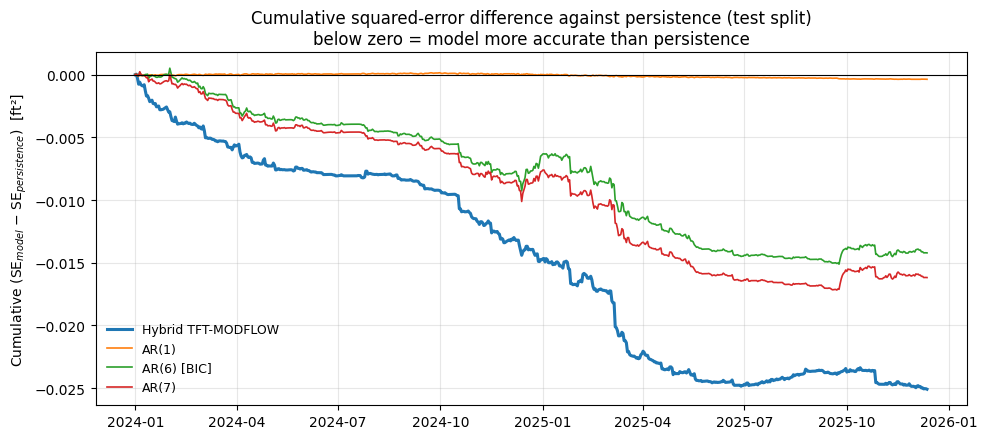

In [7]:
obs = eval_df["observed_ft"].to_numpy()
e_ref = eval_df[REFERENCE_MODEL].to_numpy() - obs
fig, ax = plt.subplots(figsize=(10, 4.5))
for m in MODEL_COLS:
    if m == REFERENCE_MODEL or m.startswith("Seasonal"):
        continue  # seasonal persistence is off the scale
    e = eval_df[m].to_numpy() - obs
    lw = 2.2 if m in learned else 1.2
    ax.plot(eval_df[DATE_COL], np.cumsum(e ** 2 - e_ref ** 2), label=m, linewidth=lw)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cumulative (SE$_{model}$ − SE$_{persistence}$)  [ft²]")
ax.set_title(f"Cumulative squared-error difference against persistence ({EVAL_SPLIT} split)\n"
             "below zero = model more accurate than persistence")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, f"cumulative_loss_vs_persistence_{EVAL_SPLIT}.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## 8. Export paper tables (CSV and LaTeX)

In [8]:
def to_latex_simple(df, caption, label, float_fmt="{:.4f}", index_name="Model"):
    cols = list(df.columns)
    esc = lambda s: str(s).replace("%", r"\%").replace("_", r"\_").replace("&", r"\&")
    lines = [r"\begin{table}[htbp]", r"\centering", rf"\caption{{{caption}}}", rf"\label{{{label}}}",
             r"\begin{tabular}{l" + "r" * len(cols) + "}", r"\hline",
             " & ".join([index_name] + [esc(c) for c in cols]) + r" \\", r"\hline"]
    for idx, row in df.iterrows():
        cells = []
        for c in cols:
            v = row[c]
            if isinstance(v, (int, np.integer)):
                cells.append(str(v))
            elif isinstance(v, (float, np.floating)):
                cells.append(float_fmt.format(v))
            else:
                cells.append(esc(v))
        lines.append(" & ".join([esc(idx)] + cells) + r" \\")
    lines += [r"\hline", r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)


def fmt_p(p):
    return "<0.001" if p < 0.001 else f"{p:.3f}"


def p_text(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


exports = {}
for label, tbl in [("all_days", table_all), ("measured_days", table_measured)]:
    csv_path = os.path.join(OUTPUT_DIR, f"comparison_table_{EVAL_SPLIT}_{label}.csv")
    tbl.to_csv(csv_path, index_label="model")
    paper = tbl[["n", "RMSE (ft)", "MAE (ft)", "Bias (ft)", "NSE",
                 "MSE skill vs persistence (%)", "R2 on daily change"]]
    subset_txt = "all days" if label == "all_days" else "measured days only"
    tex = to_latex_simple(
        paper,
        caption=f"One-day-ahead forecast accuracy on the {EVAL_SPLIT} period ({subset_txt}). "
                "Skill is relative to persistence; all models are scored on identical days.",
        label=f"tab:benchmarks_{EVAL_SPLIT}_{label}")
    tex_path = csv_path.replace(".csv", ".tex")
    with open(tex_path, "w", encoding="utf-8") as fh:
        fh.write(tex)
    exports[label] = (csv_path, tex_path)

dm_csv = os.path.join(OUTPUT_DIR, f"dm_tests_{EVAL_SPLIT}.csv")
dm_results.to_csv(dm_csv, index=False)

dm_paper = dm_results[dm_results["subset"] == "all days"].copy()
dm_paper = dm_paper.pivot_table(index=["model_A", "model_B"], columns="loss",
                                values=["DM_HLN", "p_two_sided"], aggfunc="first")
dm_paper.columns = [f"{stat} ({loss})" for stat, loss in dm_paper.columns]
dm_paper = dm_paper[["DM_HLN (squared)", "p_two_sided (squared)", "DM_HLN (absolute)", "p_two_sided (absolute)"]]
dm_fmt = dm_paper.copy()
for c in dm_fmt.columns:
    dm_fmt[c] = [fmt_p(v) if c.startswith("p_") else f"{v:.2f}" for v in dm_fmt[c]]
dm_fmt.index = [f"{a} vs {b}" for a, b in dm_fmt.index]
dm_fmt.columns = ["DM (SE)", "p (SE)", "DM (AE)", "p (AE)"]
dm_tex = to_latex_simple(
    dm_fmt,
    caption=f"Diebold--Mariano tests ({EVAL_SPLIT} period, h = 1, Newey--West HAC variance with "
            "Harvey--Leybourne--Newbold correction). Negative DM: first model more accurate. "
            "SE = squared error, AE = absolute error; two-sided p-values.",
    label=f"tab:dm_{EVAL_SPLIT}", index_name="Comparison")
dm_tex_path = dm_csv.replace(".csv", ".tex")
with open(dm_tex_path, "w", encoding="utf-8") as fh:
    fh.write(dm_tex)

for label, (c, t) in exports.items():
    print(f"Saved: {c}\nSaved: {t}")
print(f"Saved: {dm_csv}\nSaved: {dm_tex_path}")

Saved: results/paper_tables\comparison_table_test_all_days.csv
Saved: results/paper_tables\comparison_table_test_all_days.tex
Saved: results/paper_tables\comparison_table_test_measured_days.csv
Saved: results/paper_tables\comparison_table_test_measured_days.tex
Saved: results/paper_tables\dm_tests_test.csv
Saved: results/paper_tables\dm_tests_test.tex


## 9. Summary sentences for the response letter

In [9]:
ref = table_all.loc[REFERENCE_MODEL]
for a in learned:
    r = table_all.loc[a]
    best_bench = table_all.drop(index=list(learned)).index[0]
    rb = table_all.loc[best_bench]
    dm_p = dm_all.query("model_A == @a and model_B == @REFERENCE_MODEL and loss == 'squared'").iloc[0]
    dm_b = dm_all.query("model_A == @a and model_B == @best_bench and loss == 'squared'").iloc[0]
    print(
        f"{a}: on {int(r['n'])} {EVAL_SPLIT} days, RMSE = {r['RMSE (ft)']:.4f} ft against "
        f"{ref['RMSE (ft)']:.4f} ft for persistence (MSE skill {r['MSE skill vs persistence (%)']:+.1f} %; "
        f"DM = {dm_p['DM_HLN']:.2f}, {p_text(dm_p['p_two_sided'])}) and {rb['RMSE (ft)']:.4f} ft for the "
        f"best simple benchmark, {best_bench} (DM = {dm_b['DM_HLN']:.2f}, {p_text(dm_b['p_two_sided'])}). "
        f"It explains {100 * r['R2 on daily change']:.1f} % of the variance of the observed daily change; "
        f"level NSE is {r['NSE']:.4f} against {ref['NSE']:.4f} for persistence.\n"
    )

Hybrid TFT-MODFLOW: on 712 test days, RMSE = 0.0122 ft against 0.0135 ft for persistence (MSE skill +19.3 %; DM = -5.24, p < 0.001) and 0.0127 ft for the best simple benchmark, AR(7) (DM = -2.70, p = 0.007). It explains 19.1 % of the variance of the observed daily change; level NSE is 0.9935 against 0.9919 for persistence.

